# CFU prediction using TPM values from bulk RNA-seq

## Data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Load TPM data and CFU counts.

In [2]:
from src.tpm_data import get_all_tpm_data

# Paths to Fcnts and CFU data
fcnts_path = "C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/fcnts_timezero"
cfu_path   = "C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/all_cfus"

# Get data
data_df = get_all_tpm_data(
    fcnts_path = fcnts_path,
    cfu_path = cfu_path
)

## Pre-processing

Remove CFU = 0 samples and log-transform CFUs.

In [3]:
# Find idx where CFU = 0, then list the sample ID
zero_idx = np.where(data_df["CFU"] == 0)[0]
print(data_df.index[zero_idx].tolist())

# Check CFU values for the other 2 replicates
rep_names = ["34CEF4hr-a", "34CEF4hr-b"]
cfu_val_check = data_df.loc[rep_names]["CFU"].tolist()
print(f"CFU values for 34CEF4hr-a and 34CEF4hr-b :{cfu_val_check}")

# Remove sample
data_df = data_df[data_df["CFU"] != 0]

# Convert CFU to log 10
data_df["CFU"] = np.log10(data_df["CFU"])

['34CEF4hr-c']
CFU values for 34CEF4hr-a and 34CEF4hr-b :[20000000, 20000000]


## Training with stratified split

PLS regression CV scheme.

In [48]:
from src.split import combination_stratified_split

# Define a function to run nested EN CV
def run_nested_pls_cv(df, splits):

    scores = []

    for train_idx, test_idx in splits:
        train_df = df.iloc[train_idx]
        X_train = train_df.iloc[:, train_df.columns.str.contains("SP")]
        y_train = train_df["CFU"]

        test_df = df.iloc[test_idx]
        X_test = test_df.iloc[:, test_df.columns.str.contains("SP")]
        y_test = test_df["CFU"]

        # Create a nested hyperparameter tuning scheme
        param_grid = {
            "model__n_components": list(range(3, 20))
        }
        
        # Make pipeline for PLS regression
        pipeline = Pipeline([
                ("scaler", StandardScaler()),
                ("model", PLSRegression())
        ])

        # Setup GridSearch
        search = GridSearchCV(
            estimator = pipeline,
            cv = 5,
            param_grid = param_grid,
            scoring = "neg_mean_squared_error",
        )

        # Fit with best params
        search.fit(X_train, y_train)
        preds = search.predict(X_test)

        # Evaluate
        score = r2_score(y_test, preds)
        scores.append(score)
    
    mean_score = np.mean(scores)

    # Round
    scores = [round(score, 3) for score in scores]
    mean_score = round(mean_score, 3)

    return scores, mean_score
    
# Make stratified splits
strat_splits = combination_stratified_split(data_df, num_folds = 5, seed = 111)

# Run Nested CV
scores1, mean_score1 = run_nested_pls_cv(
    df = data_df,
    splits = strat_splits
)

print(f"R^2 for 5 folds : {scores1}")
print(f"Mean R^2 : {mean_score1}")

R^2 for 5 folds : [0.845, 0.826, 0.818, 0.863, 0.861]
Mean R^2 : 0.843


## Training with held-out combination(s)

Train on all single-drug data, test on all combination data.

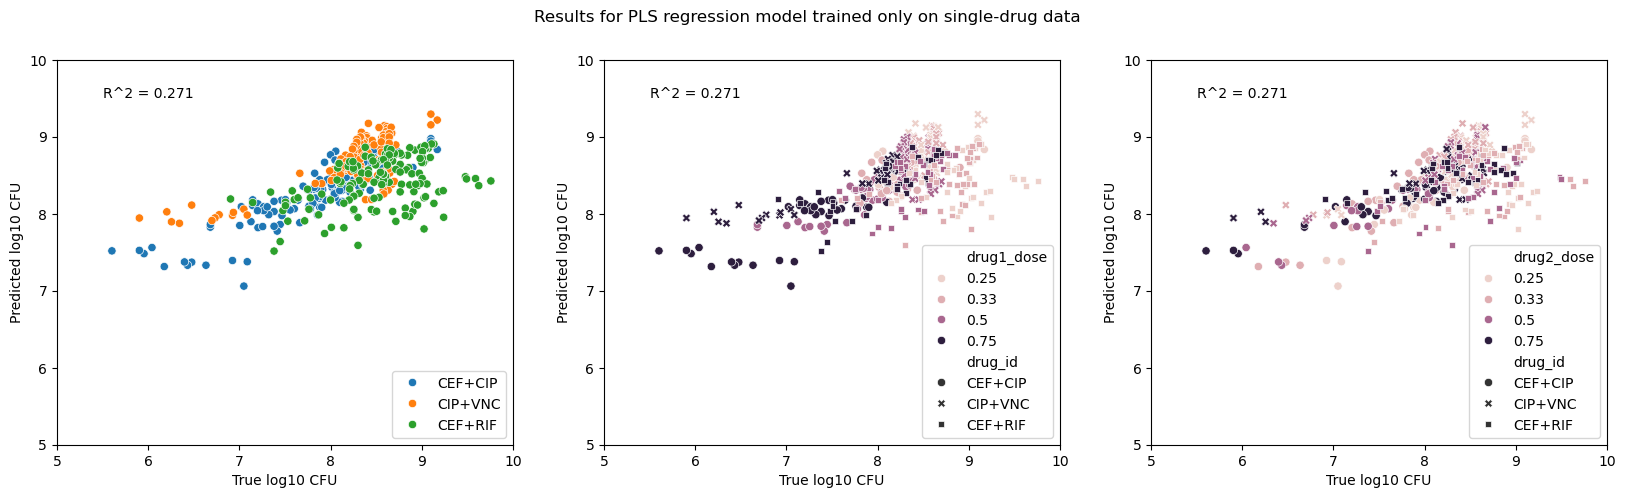

In [14]:
def held_out_combination_eval(df):
    """
    Dataframe must have the metadata attached to it
    """
    single = df[df["num_drugs"] == 1]
    combo = df[df["num_drugs"] == 2]

    # Train test split
    X_train = single.iloc[:, single.columns.str.contains("SP")]
    y_train = single["CFU"]

    X_test = combo.iloc[:, combo.columns.str.contains("SP")]
    y_test = combo["CFU"]
    meta = combo.iloc[:, ~combo.columns.str.contains("SP|CFU")]

    # PLS regression 5-fold CV pipeline
    param_grid = {
        "model__n_components": list(range(3, 20))
    }
    pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", PLSRegression())
    ])
    search = GridSearchCV(
        estimator = pipeline,
        cv = 5,
        param_grid = param_grid,
        scoring = "neg_mean_squared_error",
    )
    
    # Fit and predict
    search.fit(X_train, y_train)
    y_pred = search.predict(X_test)
    score = r2_score(y_test, y_pred)

    # Store results with metadata
    results = meta.copy()
    results["true"] = y_test.to_frame()
    results["pred"] = y_pred

    # Plot
    fig, axes = plt.subplots(1, 3, figsize = (20, 5))

    sns.scatterplot(
        results,
        x = "true",
        y = "pred",
        hue = "drug_id",
        ax = axes[0]
    )

    sns.scatterplot(
        results,
        x = "true",
        y = "pred",
        hue = "drug1_dose",
        style = "drug_id",
        ax = axes[1]
    )

    sns.scatterplot(
        results,
        x = "true",
        y = "pred",
        hue = "drug2_dose",
        style = "drug_id",
        ax = axes[2]
    )

    # Set axis limits and R^2 annotation
    for ax in axes:
        ax.set_xlim(5, 10)
        ax.set_ylim(5, 10)
        ax.text(5.5, 9.5, f"R^2 = {round(score, 3)}")
        ax.set_xlabel("True log10 CFU")
        ax.set_ylabel("Predicted log10 CFU")
        ax.legend(loc = "lower right")
    
    fig.suptitle("Results for PLS regression model trained only on single-drug data")

held_out_combination_eval(data_df)

## Training with sparse combination matrix

Train on single-drug data and dose-matched diagonal of combination matrix.

In [4]:
def sparse_diag_eval(df, dose_matched):

    # If dose-matched, then use the forward diagonal of the matrix
    if dose_matched:
        mask = (df["num_drugs"] == 1) | ((df["drug1_dose"]) == (df["drug2_dose"]))
        word = "dose-matched"
    
    # Else, use the backward diagonal of the matrix
    else:
        cross_dose_map = {
            0.25: 0.75,
            0.33: 0.50,
            0.50: 0.33,
            0.75: 0.25
        }

        # Map drug 1 dose to corresponding drug 2 dose, then generate boolean mask
        mapped = np.array([cross_dose_map.get(dose, np.nan) for dose in df["drug1_dose"].to_numpy()])
        mask = df["drug2_dose"].to_numpy() == mapped
        mask = (df["num_drugs"] == 1) | mask
        word = "dose-swapped"

    train_df = df[mask]
    test_df = df[~mask]

    # Train-test split
    X_train = train_df.iloc[:, train_df.columns.str.contains("SP")]
    y_train = train_df["CFU"]

    X_test = test_df.iloc[:, test_df.columns.str.contains("SP")]
    y_test = test_df["CFU"]
    meta = test_df.iloc[:, ~test_df.columns.str.contains("SP|CFU")]

    # PLS regression CV pipeline
    param_grid = {
        "model__n_components": list(range(3, 20))
    }

    # Make pipeline for PLS regression
    pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", PLSRegression())
    ])

    # Grid search
    search = GridSearchCV(
        estimator = pipeline,
        cv = 5,
        param_grid = param_grid,
        scoring = "neg_mean_squared_error",
    )

    # Fit with best params
    search.fit(X_train, y_train)
    y_pred = search.predict(X_test)

    # Evaluate
    score = r2_score(y_test, y_pred)

    # Store results with metadata
    results = meta.copy()
    results["true"] = y_test.to_frame()
    results["pred"] = y_pred

    # Plot
    fig, axes = plt.subplots(1, 3, figsize = (20, 5))

    sns.scatterplot(
        results,
        x = "true",
        y = "pred",
        hue = "drug_id",
        ax = axes[0]
    )

    sns.scatterplot(
        results,
        x = "true",
        y = "pred",
        hue = "drug1_dose",
        style = "drug_id",
        ax = axes[1]
    )

    sns.scatterplot(
        results,
        x = "true",
        y = "pred",
        hue = "drug2_dose",
        style = "drug_id",
        ax = axes[2]
    )

    # Set axis limits and R^2 annotation
    for ax in axes:
        ax.set_xlim(5, 10)
        ax.set_ylim(5, 10)
        ax.text(5.5, 9.5, f"R^2 = {round(score, 3)}")
        ax.set_xlabel("True log10 CFU")
        ax.set_ylabel("Predicted log10 CFU")
        ax.legend(loc = "lower right")
    
    fig.suptitle(f"Results for PLS regression model trained only single-drug and sparse, {word} combination data")

    # Extract and return best model 
    best_model = search.best_estimator_

    return best_model

Forward diagonal of combinatio matrix.

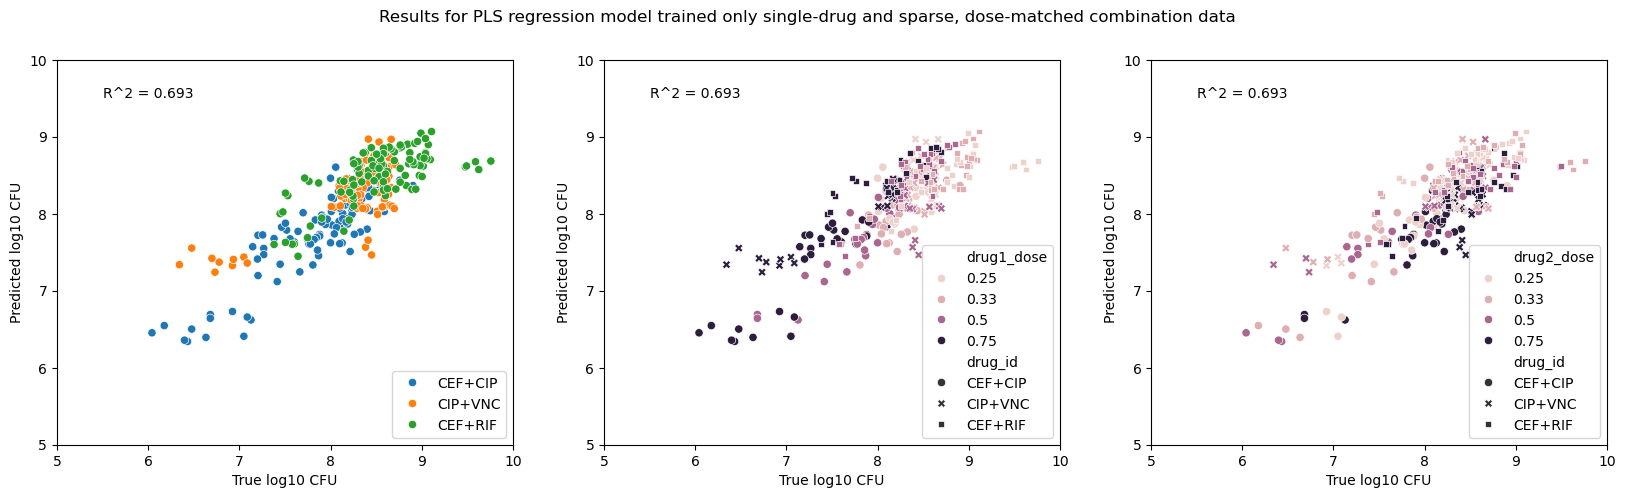

In [5]:
forward_model = sparse_diag_eval(data_df, dose_matched = True)

(array([  7.,   6.,  59., 120., 366., 690., 631., 261.,  48.,   3.]),
 array([-0.01764283, -0.01455762, -0.01147241, -0.00838719, -0.00530198,
        -0.00221677,  0.00086845,  0.00395366,  0.00703887,  0.01012408,
         0.0132093 ]),
 <BarContainer object of 10 artists>)

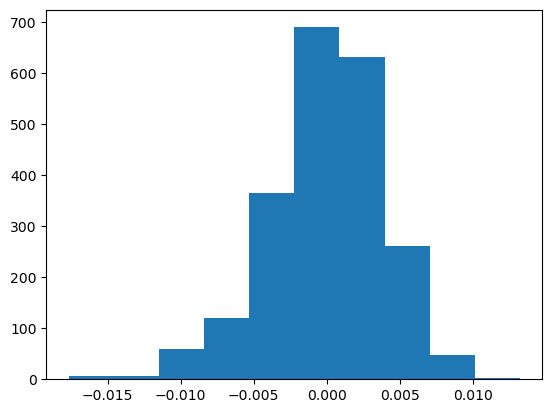

In [17]:
plt.hist(np.ndarray.flatten(forward_model.named_steps["model"].coef_))

Train on single-drug data and dose-swapped diagonal of combination matrix.

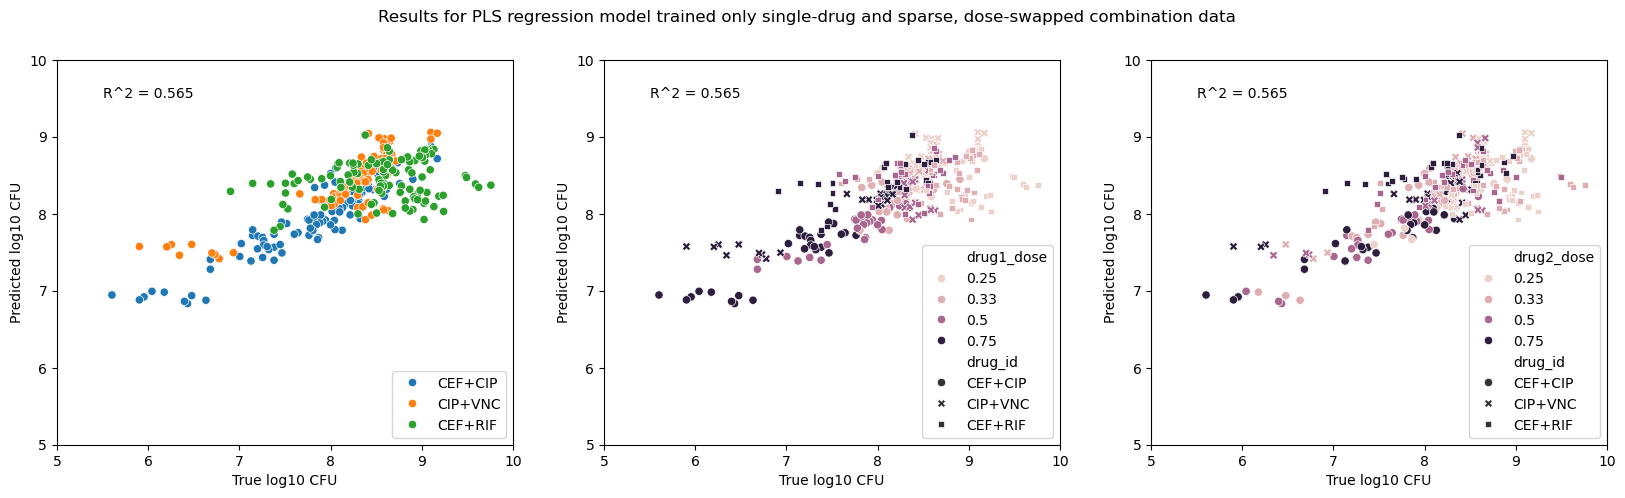

In [16]:
sparse_diag_eval(data_df, dose_matched = False)

## Training with successively more combination data

Implement a gradient of increasing combination data. Add 10 random combination datapoints along x-axis. Each point along the x-axis should contain X different splits, allowing for consistent evaluation. Then, show the mean and std of the R^2 on the y-axis for each datapoint. Look for a plateau of R^2. Then isolate that point and look at mechanistic underpinnings. (or look at importances over time??)

In [85]:
def random_combination_splits(
        data_df,
        n_combo_datapoints,
        n_splits,
        seed = None
): 
    """
    Generate a specified number of train-test splits with a specified number of combination datapoints in the training set

    Args:
        data_df            : Dataframe with integers on index and attached metadata
        n_combo_datapoints : Number of combinatino datapoints to include in training set
        n_splits           : Number of different train-test splits to generate
        seed               : Random seed for numpy

    Returns:
        splits : List of tuples of train idx and test idx
    """
    # Reset index
    df = data_df.copy().reset_index()
    splits = []
    rng = np.random.default_rng(seed)

    # Get combination idx and single-drug idx
    combo_idx = df.index[df["num_drugs"] == 2].to_numpy()
    single_idx = df.index[df["num_drugs"] == 1].to_numpy()

    # Store combo dataframe for reference
    combo_df = df.iloc[combo_idx]
    n_combos = len(combo_df["drug_id"].unique())

    for i in range(n_splits):
        
        # For each drug pair, get n random combination datapoints
        random_idx = []

        for drug in combo_df["drug_id"].unique():

            # Subset to drug
            drug_index = combo_df.index[combo_df["drug_id"] == drug].to_numpy()
            drug_random_idx = rng.choice(drug_index, size = n_combo_datapoints // n_combos, replace = False)
            random_idx.append(drug_random_idx)

        # Array and flatten
        random_idx = np.ndarray.flatten(np.array(random_idx))

        # Train and test idx
        train_idx= np.concatenate((single_idx, random_idx))
        test_idx = np.array(list(set(df.index.to_numpy()) - set(train_idx)))
        idx_tuple = (train_idx, test_idx)
        splits.append(idx_tuple)

    return splits


def plot_r2_over_data_increase(
        df,
        step_size,
        n_splits,
        seed = None
):
    """
    Plot R^2 performance over time as more combination data is incrementaly added to the training set.

    Args:
        df        : Dataframe with attached metadata
        step_size : Number of combination datapoints to add from each drug pair at each increment
        n_splits  : Number of train-test splits to generate per increment
        seed      : Random seed for numpy

    Returns:
        Plot where x = # combination datapoints in training, y = R^2
    """
    # Filter out metadata
    X = df.iloc[:, df.columns.str.contains("SP")]
    y = df["CFU"]

    # Number of combination datapoints
    n_combo_data = (df["num_drugs"] == 2).sum()
    scores = []

    # Loop through # of 
    for i in range(0, n_combo_data, step_size):

        # Get train-test splits
        splits = random_combination_splits(
            data_df = df,
            n_combo_datapoints = i,
            n_splits = n_splits,
            seed = seed
        )
        split_scores = []

        # Train and evaluate a model for each split
        for train_idx, test_idx in splits:

            # Train-test split
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # PLS regression CV pipeline
            param_grid = {
                "model__n_components": list(range(3, 15))
            }

            # Make pipeline for PLS regression
            pipeline = Pipeline([
                    ("scaler", StandardScaler()),
                    ("model", PLSRegression())
            ])

            # Grid search
            search = GridSearchCV(
                estimator = pipeline,
                cv = 5,
                param_grid = param_grid,
                scoring = "neg_mean_squared_error",
            )

            # Fit with best params
            search.fit(X_train, y_train)
            y_pred = search.predict(X_test)

            # Evaluate
            score = r2_score(y_test, y_pred)
            split_scores.append(score)

        # Add to overall score tracker
        scores.append(split_scores)
    
    scores = np.array(scores)

    # Convert to dataframe
    results = pd.DataFrame(scores) 
    results["n_combo"] = list(range(0, n_combo_data, step_size))
    results = results.melt(id_vars = ["n_combo"], value_name = "R^2").drop(columns = ["variable"])

    # Plot
    ax = sns.stripplot(results, x = "n_combo", y = "R^2")
    sns.pointplot(
        results, 
        x = "n_combo", 
        y = "R^2", 
        ax = ax, 
        errorbar = "sd", 
        color = "red",     
        linewidth = 1,
        markersize = 4,
        err_kws = {"linewidth": 1})

    # Customize
    ax.set_title("R^2 as more combination data is added to the training set")
    ax.set_xlabel("Number of combination datapoints added to training set")
    ax.set_ylabel("R^2")

    plt.show()

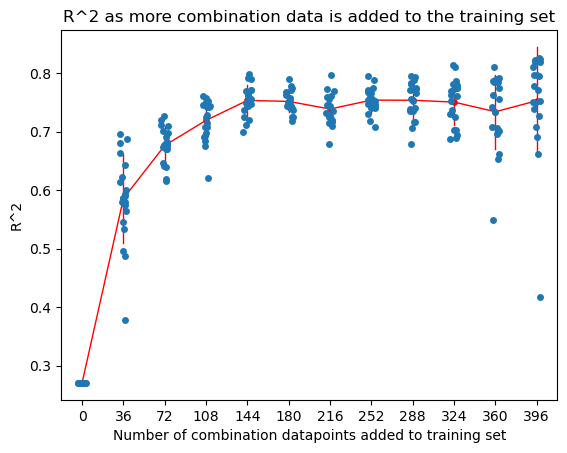

In [86]:
plot_r2_over_data_increase(
    df = data_df,
    step_size = 36,
    n_splits = 20,
    seed = 111
)

## Optimizing necessary combinations (fixed test set)

Function to plot predictions with specified train and test mask.

In [13]:
def plot_with_specified_mask(df, train_mask, test_mask, title):

    train_df = df[train_mask]
    test_df = df[test_mask]

    # Train-test split
    X_train = train_df.iloc[:, train_df.columns.str.contains("SP")]
    y_train = train_df["CFU"]

    X_test = test_df.iloc[:, test_df.columns.str.contains("SP")]
    y_test = test_df["CFU"]
    meta = test_df.iloc[:, ~test_df.columns.str.contains("SP|CFU")]

    # PLS regression CV pipeline
    param_grid = {
        "model__n_components": list(range(3, 20))
    }

    # Make pipeline for PLS regression
    pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", PLSRegression())
    ])

    # Grid search
    search = GridSearchCV(
        estimator = pipeline,
        cv = 5,
        param_grid = param_grid,
        scoring = "neg_mean_squared_error",
    )

    # Fit with best params
    search.fit(X_train, y_train)
    y_pred = search.predict(X_test)

    # Evaluate
    score = r2_score(y_test, y_pred)

    # Store results with metadata
    results = meta.copy()
    results["true"] = y_test.to_frame()
    results["pred"] = y_pred

    # Plot
    fig, axes = plt.subplots(1, 3, figsize = (20, 5))

    sns.scatterplot(
        results,
        x = "true",
        y = "pred",
        hue = "drug_id",
        ax = axes[0]
    )

    sns.scatterplot(
        results,
        x = "true",
        y = "pred",
        hue = "drug1_dose",
        style = "drug_id",
        ax = axes[1]
    )

    sns.scatterplot(
        results,
        x = "true",
        y = "pred",
        hue = "drug2_dose",
        style = "drug_id",
        ax = axes[2]
    )

    # Set axis limits and R^2 annotation
    for ax in axes:
        ax.set_xlim(5, 10)
        ax.set_ylim(5, 10)
        ax.text(5.5, 9.5, f"R^2 = {round(score, 3)}")
        ax.set_xlabel("True log10 CFU")
        ax.set_ylabel("Predicted log10 CFU")
        ax.legend(loc = "lower right")
    
    fig.suptitle(title)

    # Extract and return best model 
    best_model = search.best_estimator_

    return best_model

Fixed test set mask.

In [14]:
# Define fixed test set mask
mask1 = (data_df["drug1_dose"] == 0.50) & (data_df["drug2_dose"] == 0.33)
mask2 = (data_df["drug1_dose"] == 0.75) & (data_df["drug2_dose"] == 0.33)
mask3 = (data_df["drug1_dose"] == 0.75) & (data_df["drug2_dose"] == 0.50)
mask4 = (data_df["drug1_dose"] == 0.33) & (data_df["drug2_dose"] == 0.50)
mask5 = (data_df["drug1_dose"] == 0.33) & (data_df["drug2_dose"] == 0.75) 
mask6 = (data_df["drug1_dose"] == 0.50) & (data_df["drug2_dose"] == 0.75) 

test_mask = mask1 | mask2 | mask3 | mask4 | mask5 | mask6

Train on diagonal.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",10
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06


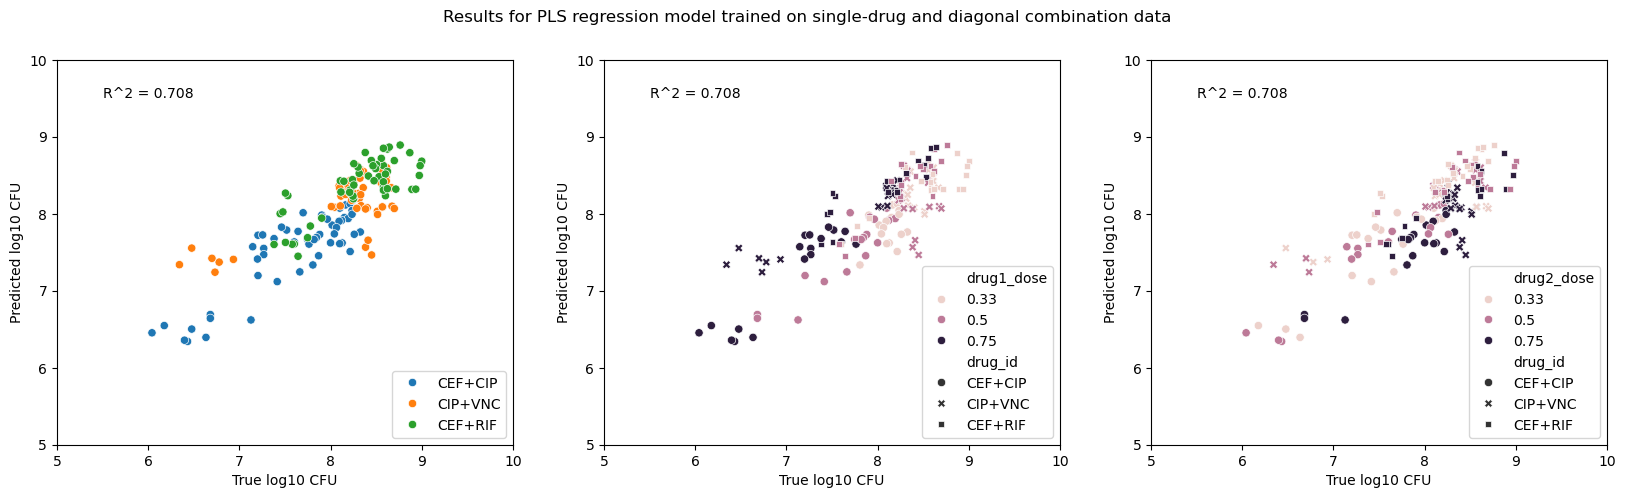

In [15]:
diag1_mask = (data_df["num_drugs"] == 1) | ((data_df["drug1_dose"]) == (data_df["drug2_dose"]))

plot_with_specified_mask(
    df = data_df,
    train_mask = diag1_mask,
    test_mask = test_mask,
    title = "Results for PLS regression model trained on single-drug and diagonal combination data"
)

Train on first row.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",8
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06


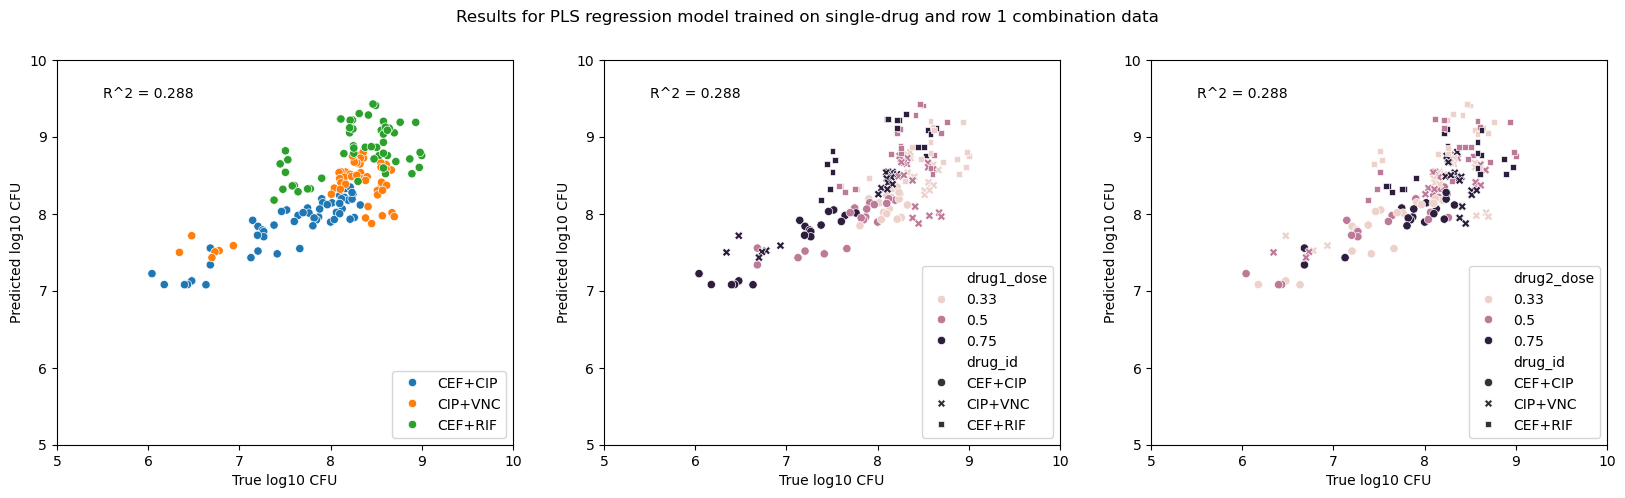

In [16]:
row1_mask = (data_df["num_drugs"] == 1) | (data_df["drug1_dose"] == 0.25)

plot_with_specified_mask(
    df = data_df,
    train_mask = row1_mask,
    test_mask = test_mask,
    title = "Results for PLS regression model trained on single-drug and row 1 combination data"
)

Train on first column.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",10
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06


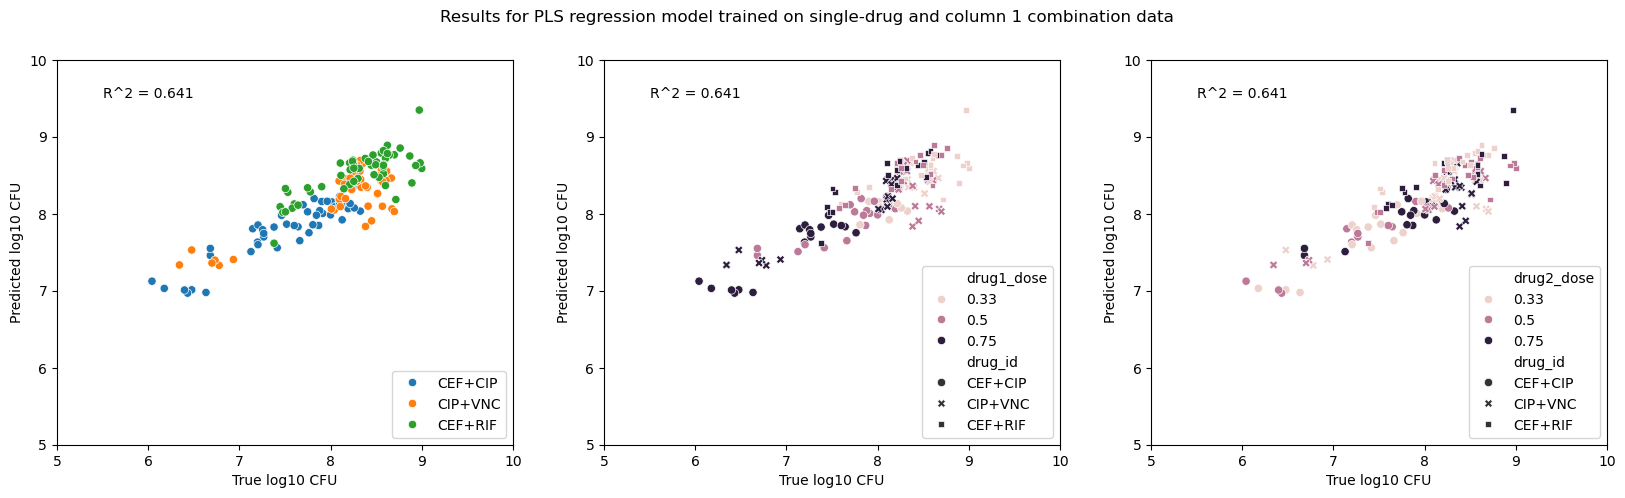

In [19]:
col1_mask = (data_df["num_drugs"] == 1) | (data_df["drug2_dose"] == 0.25)

plot_with_specified_mask(
    df = data_df,
    train_mask = col1_mask,
    test_mask = test_mask,
    title = "Results for PLS regression model trained on single-drug and column 1 combination data"
)

Train on first column and row.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",7
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06


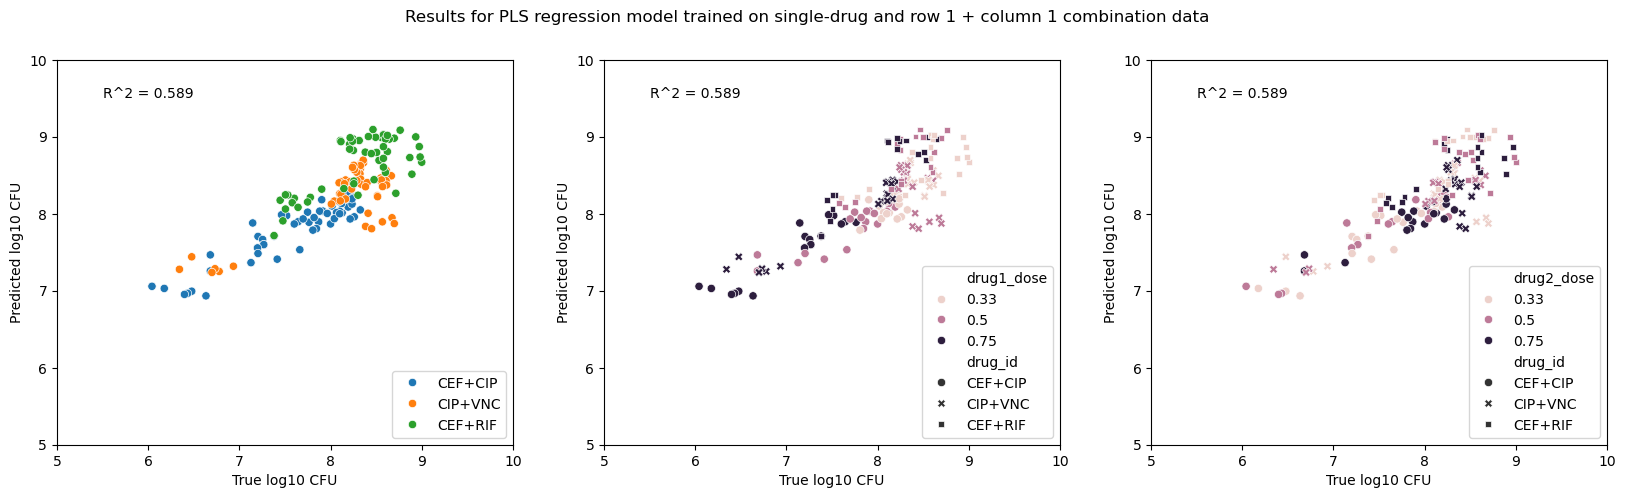

In [20]:
t_mask = (data_df["num_drugs"] == 1) | (data_df["drug1_dose"] == 0.25) | (data_df["drug2_dose"] == 0.25)

plot_with_specified_mask(
    df = data_df,
    train_mask = t_mask,
    test_mask = test_mask,
    title = "Results for PLS regression model trained on single-drug and row 1 + column 1 combination data"
)

Train on first row and diagonal.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",8
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06


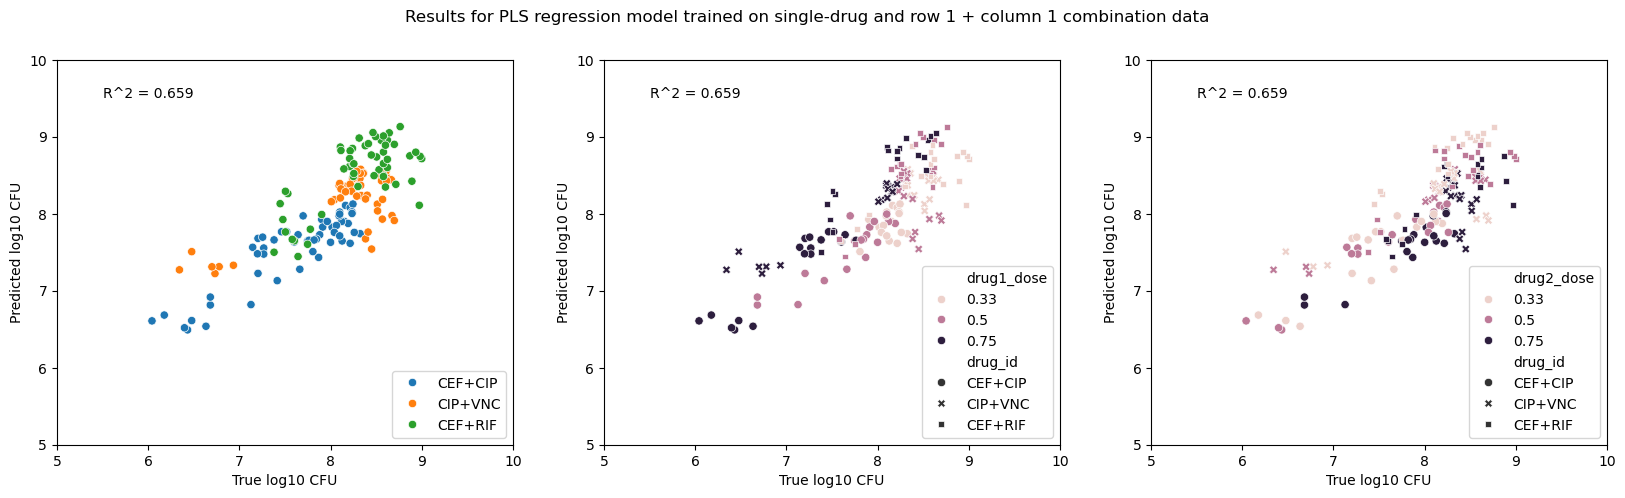

In [ ]:
row1_diag_mask = (data_df["num_drugs"] == 1) | (data_df["drug1_dose"] == 0.25) | ((data_df["drug1_dose"]) == (data_df["drug2_dose"]))

plot_with_specified_mask(
    df = data_df,
    train_mask = row1_diag_mask,
    test_mask = test_mask,
    title = "Results for PLS regression model trained on single-drug and row 1 + column 1 combination data"
)

Train on first column and diagonal.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",7
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06


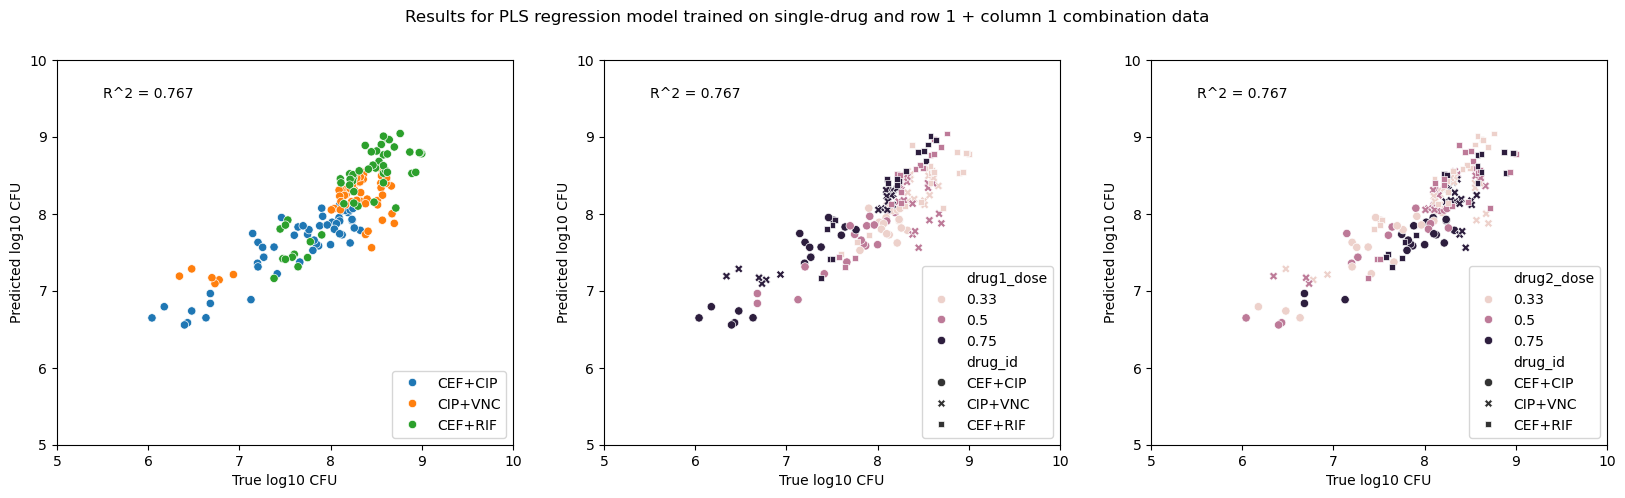

In [22]:
col1_diag_mask = (data_df["num_drugs"] == 1) | (data_df["drug2_dose"] == 0.25) | ((data_df["drug1_dose"]) == (data_df["drug2_dose"]))

plot_with_specified_mask(
    df = data_df,
    train_mask = col1_diag_mask,
    test_mask = test_mask,
    title = "Results for PLS regression model trained on single-drug and row 1 + column 1 combination data"
)

Train on first row, first column, and diagonal.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",7
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06


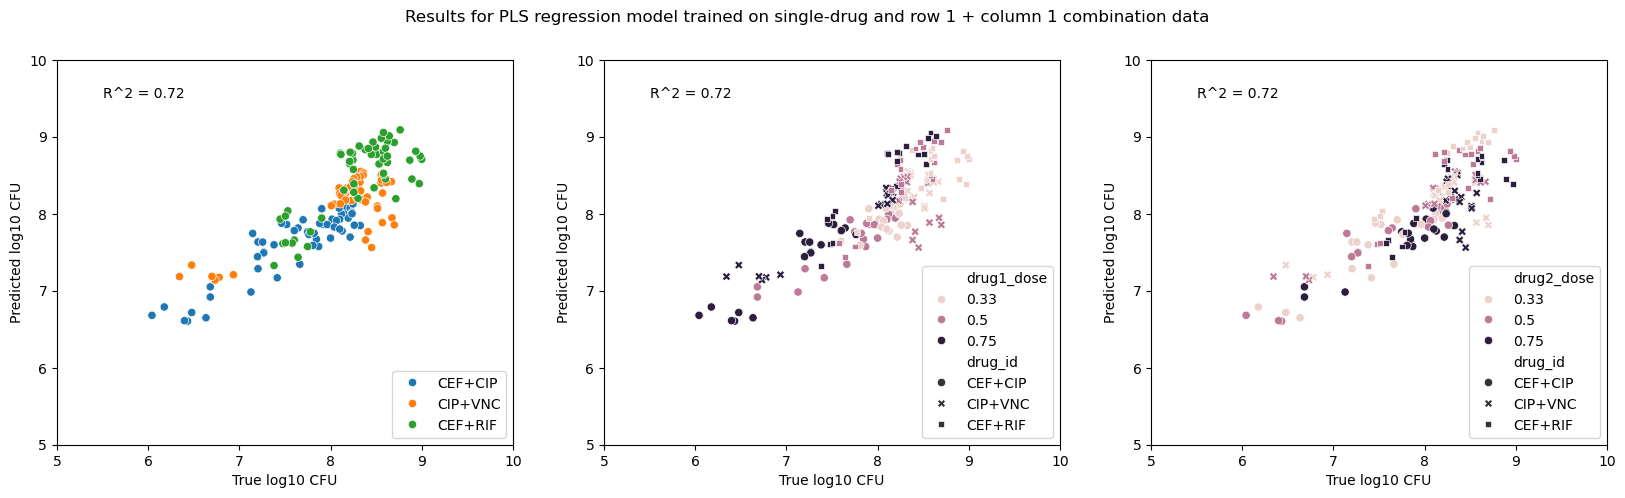

In [23]:
all_mask = (data_df["num_drugs"] == 1) | (data_df["drug1_dose"] == 0.25)| (data_df["drug2_dose"] == 0.25) | ((data_df["drug1_dose"]) == (data_df["drug2_dose"]))

plot_with_specified_mask(
    df = data_df,
    train_mask = all_mask,
    test_mask = test_mask,
    title = "Results for PLS regression model trained on single-drug and row 1 + column 1 combination data"
)